## Setup and Imports

In [27]:
import os
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import pandas as pd
from torch.utils.data import DataLoader

# custom project modules
# dataset class (used to load and preprocess the chest X-ray images)
from dataset import ChestXrayDataset, get_transforms

# models: used to load different CNN architectures, including pretrained models like ResNet and DenseNet
from models import build_model

# classifier module: defines the training, validation, and testing steps using pytorch lightning
from classifier import ClassificationTask

# noise injection functions: used to add noise to images during the testing phase to evaluate model robustness
from noise import add_poisson, add_gaussian

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Load Sample Data

In [28]:
# set random seed for reproducibility
np.random.seed(0)
torch.manual_seed(0)

# load labels from CSV
labels_df = pd.read_csv('data/labels.csv')

# create subset: sample 100 images from each split to keep runtime under 1 minute
subset_size = 100
train_subset = labels_df[labels_df['split'] == 'train'].sample(n=min(int(subset_size*0.7), len(labels_df[labels_df['split'] == 'train'])), random_state=0)
val_subset = labels_df[labels_df['split'] == 'val'].sample(n=min(int(subset_size*0.15), len(labels_df[labels_df['split'] == 'val'])), random_state=0)
test_subset = labels_df[labels_df['split'] == 'test'].sample(n=min(int(subset_size*0.15), len(labels_df[labels_df['split'] == 'test'])), random_state=0)

print(f"Train subset size: {len(train_subset)}")
print(f"Val subset size: {len(val_subset)}")
print(f"Test subset size: {len(test_subset)}")

subset_info = {
    'train': train_subset['image_path'].tolist(),
    'val': val_subset['image_path'].tolist(),
    'test': test_subset['image_path'].tolist()
}

import json
with open('notebook_subset.json', 'w') as f:
    json.dump(subset_info, f, indent=2)
print("\nSubset paths saved to notebook_subset.json for reproducibility")

train_transform, val_transform, test_transform = get_transforms(img_size=224)

# create datasets using the chest_xray folder structure (not CSV, to avoid path issues)
train_dataset = ChestXrayDataset(
    root_dir='chest_xray_subset',
    split='train',
    transform=train_transform,
    poisson_intensity=0,
    gaussian_intensity=0
)

val_dataset = ChestXrayDataset(
    root_dir='chest_xray_subset',
    split='val',
    transform=val_transform,
    poisson_intensity=0,
    gaussian_intensity=0
)

test_dataset = ChestXrayDataset(
    root_dir='chest_xray_subset',
    split='test',
    transform=test_transform,
    poisson_intensity=0,
    gaussian_intensity=0
)

from torch.utils.data import Subset

# Create deterministic indices for subsets using the fixed seed
train_indices = np.random.choice(len(train_dataset), min(len(train_subset), len(train_dataset)), replace=False)
val_indices = np.random.choice(len(val_dataset), min(len(val_subset), len(val_dataset)), replace=False)
test_indices = np.random.choice(len(test_dataset), min(len(test_subset), len(test_dataset)), replace=False)

# Use only the sampled indices
train_dataset = Subset(train_dataset, train_indices)
val_dataset = Subset(val_dataset, val_indices)
test_dataset = Subset(test_dataset, test_indices)

print(f"\nSubset datasets created:")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train subset size: 70
Val subset size: 15
Test subset size: 15

Subset paths saved to notebook_subset.json for reproducibility

Subset datasets created:
Train dataset size: 70
Val dataset size: 15
Test dataset size: 15


## Visualize Sample Images

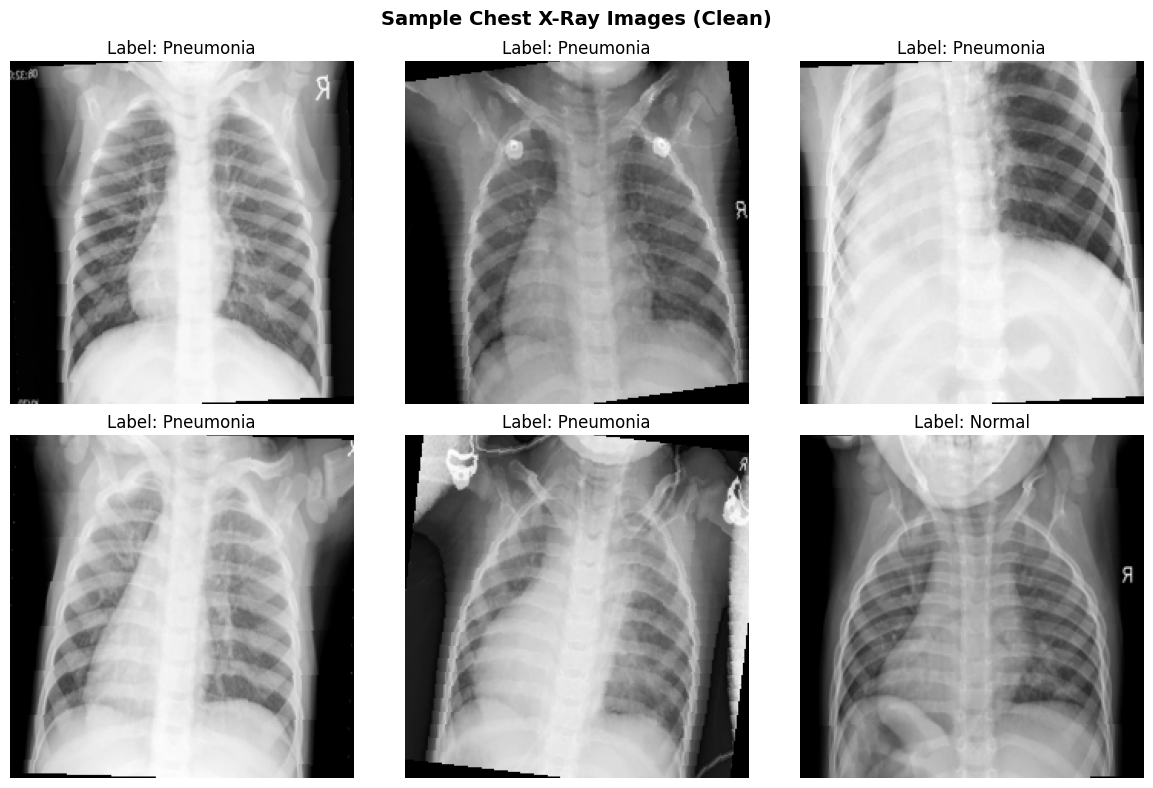

In [29]:
sample_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Sample Chest X-Ray Images (Clean)', fontsize=14, fontweight='bold')

label_names = ['Normal', 'Pneumonia']

for idx, (img, label) in enumerate(sample_loader):
    if idx >= 6:
        break
    ax = axes.flatten()[idx]
    img_np = img.squeeze().numpy()
    ax.imshow(img_np, cmap='gray')
    ax.set_title(f'Label: {label_names[label.item()]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Quick Training Run on ResNet 18, one of our stronger performing results

In [30]:

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

task = ClassificationTask(backbone='resnet18', lr=1e-3)

trainer = pl.Trainer(
    max_epochs=5,
    accelerator='auto',
    log_every_n_steps=1,
    enable_progress_bar=True,
    enable_model_summary=False,
)

print("Starting ResNet18 training...")
print(f"Note: Training on small subset ({len(train_dataset)} images) for demonstration")
trainer.fit(task, train_dataloaders=train_loader, val_dataloaders=val_loader)
print("Training complete!")


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Starting ResNet18 training...
Note: Training on small subset (70 images) for demonstration
                                                                           

/Users/buiswrld/Documents/School/uci-2025-2026/CS 184A/Project/xray-noise/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.
/Users/buiswrld/Documents/School/uci-2025-2026/CS 184A/Project/xray-noise/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.


Epoch 2: 100%|██████████| 5/5 [00:00<00:00,  6.54it/s, v_num=7, val_loss=10.30, val_auroc=1.000, train_auroc=1.000]

/Users/buiswrld/Documents/School/uci-2025-2026/CS 184A/Project/xray-noise/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)


Epoch 4: 100%|██████████| 5/5 [00:00<00:00,  6.13it/s, v_num=7, val_loss=4.330, val_auroc=1.000, train_auroc=0.982] 

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 5/5 [00:00<00:00,  5.01it/s, v_num=7, val_loss=4.330, val_auroc=1.000, train_auroc=0.982]
Training complete!


## Part 4: Train Basic CNN Model

Now train a basic CNN model to compare performance with ResNet18.


In [31]:
basic_task = ClassificationTask(backbone='basic', lr=1e-3)
trainer_basic = pl.Trainer(
    max_epochs=5,
    accelerator='auto',
    log_every_n_steps=1,
    enable_progress_bar=True,
    enable_model_summary=False,
)

print("Starting Basic CNN training...")
trainer_basic.fit(basic_task, train_dataloaders=train_loader, val_dataloaders=val_loader)
print("Basic CNN training complete!")

resnet_model = task
basic_model = basic_task

print(f"\nBoth models trained successfully!")
print(f"ResNet18 model: {resnet_model}")
print(f"CNN (Basic) model: {basic_model}")


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Starting Basic CNN training...
Epoch 4: 100%|██████████| 5/5 [00:00<00:00,  9.06it/s, v_num=8, val_loss=0.543, val_auroc=0.389, train_auroc=0.501]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 5/5 [00:00<00:00,  8.93it/s, v_num=8, val_loss=0.543, val_auroc=0.389, train_auroc=0.501]
Basic CNN training complete!

Both models trained successfully!
ResNet18 model: ClassificationTask(
  (model): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

## Part 5: Demonstrate Noise Injection

Show how combined Gaussian and Poisson noise affects X-ray images at different intensity levels.

Loaded image: NORMAL2-IM-0285-0001.jpeg
Image size: (1456, 839)
ALERT: Poisson noise being applied with intensity  2
ALERT: Electronic noise being applied with intensity  2
ALERT: Poisson noise being applied with intensity  4
ALERT: Electronic noise being applied with intensity  4
ALERT: Poisson noise being applied with intensity  6
ALERT: Electronic noise being applied with intensity  6


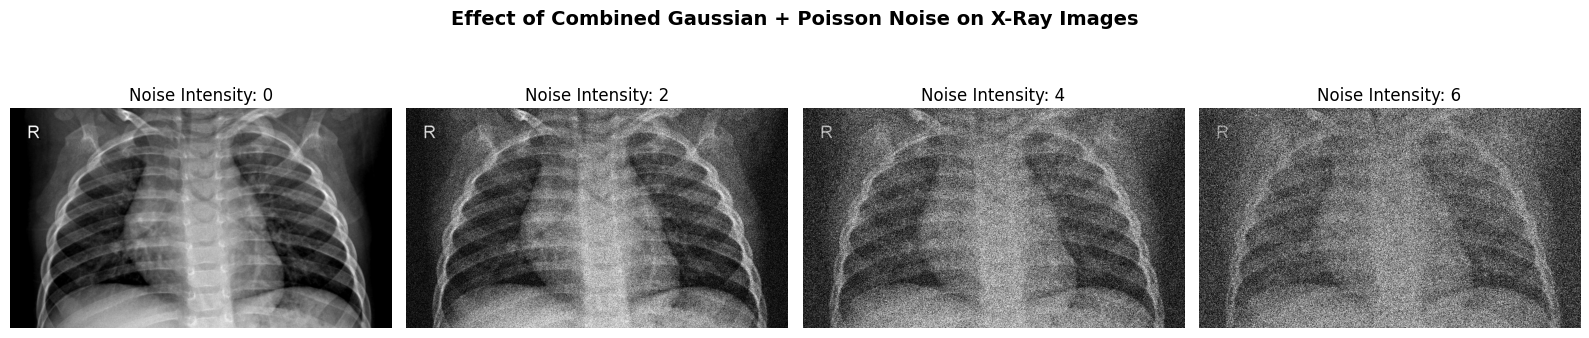

In [32]:
from pathlib import Path

# find random image from test set
test_normal_dir = Path('chest_xray_subset/test/NORMAL')
test_pneumonia_dir = Path('chest_xray_subset/test/PNEUMONIA')

normal_images = list(test_normal_dir.glob('*.jpeg'))
sample_image_path = normal_images[0]

sample_img_pil = Image.open(sample_image_path).convert('L')

print(f"Loaded image: {sample_image_path.name}")
print(f"Image size: {sample_img_pil.size}")

# create noisy versions at different intensities
noise_intensities = [0, 2, 4, 6]

fig, axes = plt.subplots(1, len(noise_intensities), figsize=(16, 4))
fig.suptitle('Effect of Combined Gaussian + Poisson Noise on X-Ray Images', 
             fontsize=14, fontweight='bold')

for idx, intensity in enumerate(noise_intensities):
    if intensity > 0:
        noisy_img = add_poisson(sample_img_pil.copy(), intensity=intensity)
        noisy_img = add_gaussian(noisy_img, intensity=intensity)
    else:
        noisy_img = sample_img_pil.copy()
    
    ax = axes[idx]
    ax.imshow(noisy_img, cmap='gray')
    ax.set_title(f'Noise Intensity: {intensity}')
    ax.axis('off')

plt.tight_layout()
plt.show()


## Part 6: Evaluate on Noisy Test Set

Evaluate the ResNet34 model on test images with varying noise levels.

In [33]:
def evaluate_on_noise_level(model, poisson_intensity, gaussian_intensity):
    """Evaluate model on test set with specified noise levels, matching main.py approach"""
    # create test loader with the given noise intensities
    test_loader = DataLoader(
        ChestXrayDataset(
            root_dir='chest_xray_subset',
            split='test',
            transform=test_transform,
            poisson_intensity=poisson_intensity,
            gaussian_intensity=gaussian_intensity
        ),
        batch_size=16,
        shuffle=False,
        num_workers=0
    )
    
    model.eval()
    model.to(device)
    
    correct = 0
    total = 0
    
    # suppress the noise alerts
    import sys
    from io import StringIO
    old_stdout = sys.stdout
    sys.stdout = StringIO()
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            logits = model(images)
            if logits.ndim == 2 and logits.size(1) == 1:
                logits = logits.squeeze(1)
            probs = torch.sigmoid(logits)
            
            predictions = (probs >= 0.5).long()
            
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    
    sys.stdout = old_stdout
    
    accuracy = correct / total if total > 0 else 0
    return accuracy

noise_configs = [
    (0, 0, "Clean (no noise)"),
    (2, 2, "Gaussian 2 + Poisson 2"),
    (4, 4, "Gaussian 4 + Poisson 4"),
    (6, 6, "Gaussian 6 + Poisson 6"),
]

accuracies_resnet = []
accuracies_basic = []

print("Evaluating ResNet18 on noisy test sets...")
for gauss, poiss, label in noise_configs:
    acc = evaluate_on_noise_level(resnet_model, poiss, gauss)
    accuracies_resnet.append(acc)
    print(f"  {label}: Accuracy = {acc:.4f}")

print("\nEvaluating Basic CNN on noisy test sets...")
for gauss, poiss, label in noise_configs:
    acc = evaluate_on_noise_level(basic_model, poiss, gauss)
    accuracies_basic.append(acc)
    print(f"  {label}: Accuracy = {acc:.4f}")

noise_levels = [0, 2, 4, 6]


Evaluating ResNet18 on noisy test sets...
  Clean (no noise): Accuracy = 0.6667
  Gaussian 2 + Poisson 2: Accuracy = 0.2667
  Gaussian 4 + Poisson 4: Accuracy = 0.2667
  Gaussian 6 + Poisson 6: Accuracy = 0.2000

Evaluating Basic CNN on noisy test sets...
  Clean (no noise): Accuracy = 0.7333
  Gaussian 2 + Poisson 2: Accuracy = 0.7333
  Gaussian 4 + Poisson 4: Accuracy = 0.7333
  Gaussian 6 + Poisson 6: Accuracy = 0.7333


## Part 7: Visualize Model Performance vs Noise

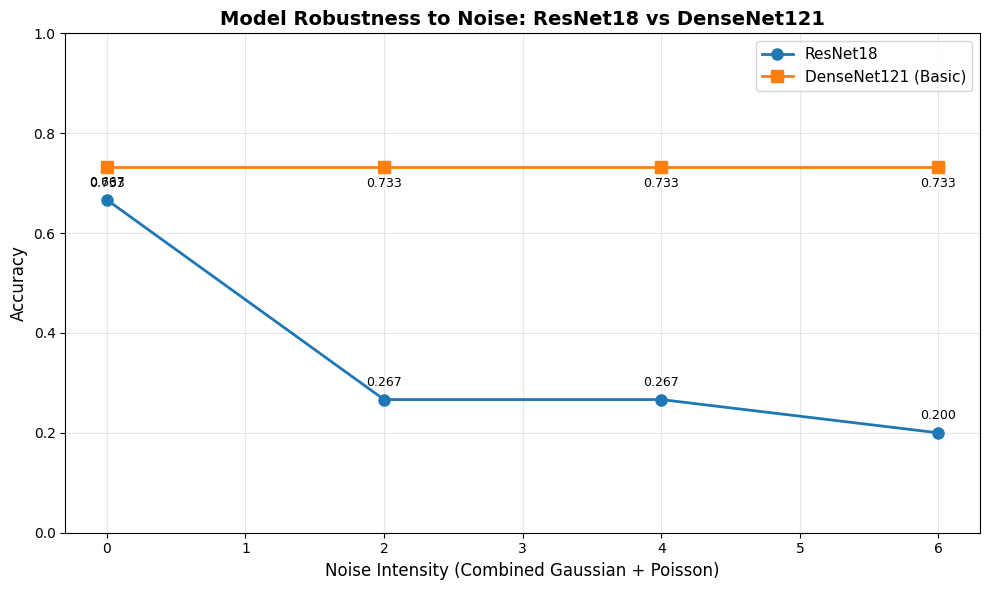

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(noise_levels, accuracies_resnet, 'o-', linewidth=2, markersize=8, label='ResNet18', color='#1f77b4')
plt.plot(noise_levels, accuracies_basic, 's-', linewidth=2, markersize=8, label='DenseNet121 (Basic)', color='#ff7f0e')
plt.xlabel('Noise Intensity (Combined Gaussian + Poisson)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Robustness to Noise: ResNet18 vs DenseNet121', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])
plt.legend(fontsize=11)

for x, y in zip(noise_levels, accuracies_resnet):
    plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
for x, y in zip(noise_levels, accuracies_basic):
    plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)

plt.tight_layout()
plt.show()
